In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold

In [2]:
df3 = pd.read_csv("../../data/merged_dataset_organized_45photic.csv")
print(df3.columns)

Index(['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'Cruise_ID', 'Cruz_Sta', 'Cast_ID',
       'Sta_ID', 'Distance', 'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line',
       'Bottom_D', 'Secchi', 'IntChl', 'IntC14', 'TimeZone', 'Visibility',
       'PHOTIC_ZONE'],
      dtype='object')


In [4]:
def calculate_photic_depth_at_threshold(group, threshold_pct):
    """Calculate depth where PAR drops to threshold_pct of 2m baseline."""
    group = group.sort_values('DEPTH').dropna(subset=['PAR'])
    
    depth_2m = group[group['DEPTH'] == 2.0]
    if len(depth_2m) == 0 or len(group) < 2:
        return np.nan
    
    surface_par = depth_2m['PAR'].iloc[0]
    if surface_par <= 0:
        return np.nan
    
    group = group[group['DEPTH'] >= 2.0].copy()
    group['PAR_pct'] = (group['PAR'] / surface_par) * 100
    
    above = group[group['PAR_pct'] >= threshold_pct]
    below = group[group['PAR_pct'] < threshold_pct]
    
    if len(above) == 0 or len(below) == 0:
        return np.nan
    
    d_a, d_b = above['DEPTH'].iloc[-1], below['DEPTH'].iloc[0]
    p_a, p_b = above['PAR_pct'].iloc[-1], below['PAR_pct'].iloc[0]
    
    return d_a + (d_b - d_a) * (p_a - threshold_pct) / (p_a - p_b)

Cross-validated correlation (10-fold) between Secchi and photic depth:
 Threshold   Mean r    Std r
----------------------------
      3.0%   0.6826   0.1131
      3.1%   0.6790   0.1231
      3.2%   0.6774   0.1326
      3.3%   0.6729   0.1426
      3.4%   0.6714   0.1471
      3.5%   0.7016   0.1085
      3.6%   0.6698   0.1330
      3.7%   0.6729   0.1267
      3.8%   0.6758   0.1196
      3.9%   0.7064   0.0683
      4.0%   0.7089   0.0693
      4.1%   0.7086   0.0718
      4.2%   0.7083   0.0783
      4.3%   0.7071   0.0845
      4.4%   0.7031   0.0919
      4.5%   0.7286   0.0440
      4.6%   0.7247   0.0547
      4.7%   0.7337   0.0351
      4.8%   0.7285   0.0401
      4.9%   0.7264   0.0433
      5.0%   0.7151   0.0602
      5.1%   0.7255   0.0461
      5.2%   0.7101   0.0662
      5.3%   0.6905   0.1058
      5.4%   0.6733   0.1367
      5.5%   0.7084   0.0737
      5.6%   0.7046   0.0809
      5.7%   0.7028   0.0862
      5.8%   0.6749   0.1183
      5.9%   0.6892   0.1014
 

/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_44997/1606884827.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=[f'{t}%' for t in top_thresholds])


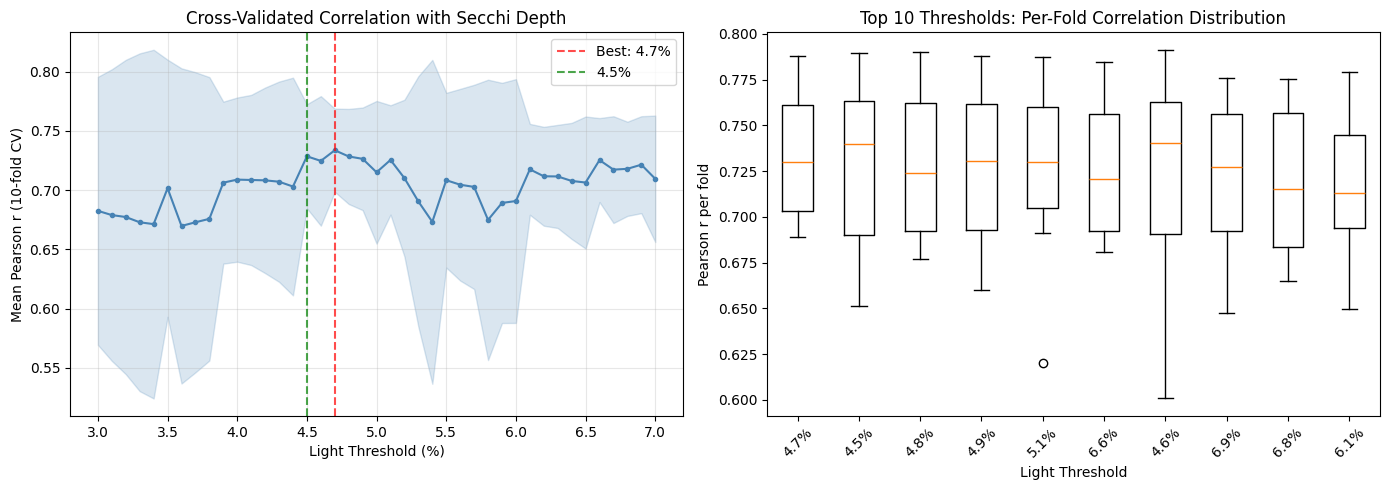

In [5]:
# Cross-validated threshold selection: 3% to 7% in 0.1% steps
thresholds_cv = [round(x * 0.1, 1) for x in range(30, 71)]

# Pre-compute photic depths for all thresholds and all casts
secchi_per_cast = df3.groupby('CAST_COUNT')['Secchi'].first()

photic_all = {}
for t in thresholds_cv:
    photic_all[t] = df3.groupby('CAST_COUNT').apply(
        lambda g, thresh=t: calculate_photic_depth_at_threshold(g, thresh), include_groups=False
    )

# Build a DataFrame: rows = casts, columns = thresholds + Secchi
cv_df = pd.DataFrame(photic_all)
cv_df['Secchi'] = secchi_per_cast

# Drop casts with no Secchi
cv_df = cv_df.dropna(subset=['Secchi'])

# 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cast_indices = np.arange(len(cv_df))

# Store per-fold correlations for each threshold
fold_correlations = {t: [] for t in thresholds_cv}

for train_idx, test_idx in kf.split(cast_indices):
    test_data = cv_df.iloc[test_idx]
    for t in thresholds_cv:
        valid = test_data[['Secchi', t]].dropna()
        if len(valid) >= 10:
            r = valid['Secchi'].corr(valid[t])
            fold_correlations[t].append(r)
        else:
            fold_correlations[t].append(np.nan)

# Compute mean and std of correlations across folds
mean_corr = {t: np.nanmean(fold_correlations[t]) for t in thresholds_cv}
std_corr = {t: np.nanstd(fold_correlations[t]) for t in thresholds_cv}

# Display results
print("Cross-validated correlation (10-fold) between Secchi and photic depth:")
print(f"{'Threshold':>10} {'Mean r':>8} {'Std r':>8}")
print("-" * 28)
for t in thresholds_cv:
    print(f"{t:>9.1f}% {mean_corr[t]:>8.4f} {std_corr[t]:>8.4f}")

best_t_cv = max(mean_corr, key=mean_corr.get)
print(f"\nBest threshold: {best_t_cv}% (mean r = {mean_corr[best_t_cv]:.4f} +/- {std_corr[best_t_cv]:.4f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

means = [mean_corr[t] for t in thresholds_cv]
stds = [std_corr[t] for t in thresholds_cv]

axes[0].plot(thresholds_cv, means, 'o-', color='steelblue', markersize=3)
axes[0].fill_between(thresholds_cv, 
                      [m - s for m, s in zip(means, stds)],
                      [m + s for m, s in zip(means, stds)],
                      alpha=0.2, color='steelblue')
axes[0].axvline(x=best_t_cv, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_t_cv}%')
axes[0].axvline(x=4.5, color='green', linestyle='--', alpha=0.7, label='4.5%')
axes[0].set_xlabel('Light Threshold (%)')
axes[0].set_ylabel('Mean Pearson r (10-fold CV)')
axes[0].set_title('Cross-Validated Correlation with Secchi Depth')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot of per-fold correlations for top candidates
top_thresholds = sorted(mean_corr, key=mean_corr.get, reverse=True)[:10]
box_data = [fold_correlations[t] for t in top_thresholds]
axes[1].boxplot(box_data, labels=[f'{t}%' for t in top_thresholds])
axes[1].set_xlabel('Light Threshold')
axes[1].set_ylabel('Pearson r per fold')
axes[1].set_title('Top 10 Thresholds: Per-Fold Correlation Distribution')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Cross-validated correlation (10-fold) between Secchi and photic depth (4.50% - 4.80%):
 Threshold   Mean r    Std r
----------------------------
     4.50%   0.7286   0.0440
     4.51%   0.7280   0.0445
     4.52%   0.7276   0.0453
     4.53%   0.7278   0.0459
     4.54%   0.7277   0.0472
     4.55%   0.7266   0.0487
     4.56%   0.7267   0.0495
     4.57%   0.7260   0.0520
     4.58%   0.7257   0.0528
     4.59%   0.7249   0.0540
     4.60%   0.7247   0.0547
     4.61%   0.7231   0.0554
     4.62%   0.7232   0.0565
     4.63%   0.7215   0.0573
     4.64%   0.7209   0.0584
     4.65%   0.7203   0.0592
     4.66%   0.7204   0.0603
     4.67%   0.7203   0.0614
     4.68%   0.7184   0.0617
     4.69%   0.7181   0.0626
     4.70%   0.7337   0.0351
     4.71%   0.7340   0.0352
     4.72%   0.7338   0.0353
     4.73%   0.7332   0.0355
     4.74%   0.7331   0.0357
     4.75%   0.7299   0.0381
     4.76%   0.7304   0.0381
     4.77%   0.7300   0.0385
     4.78%   0.7297   0.0389
     4.79%   0

/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_44997/2292848340.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data_fine, labels=[f'{t}%' for t in top_thresholds_fine])


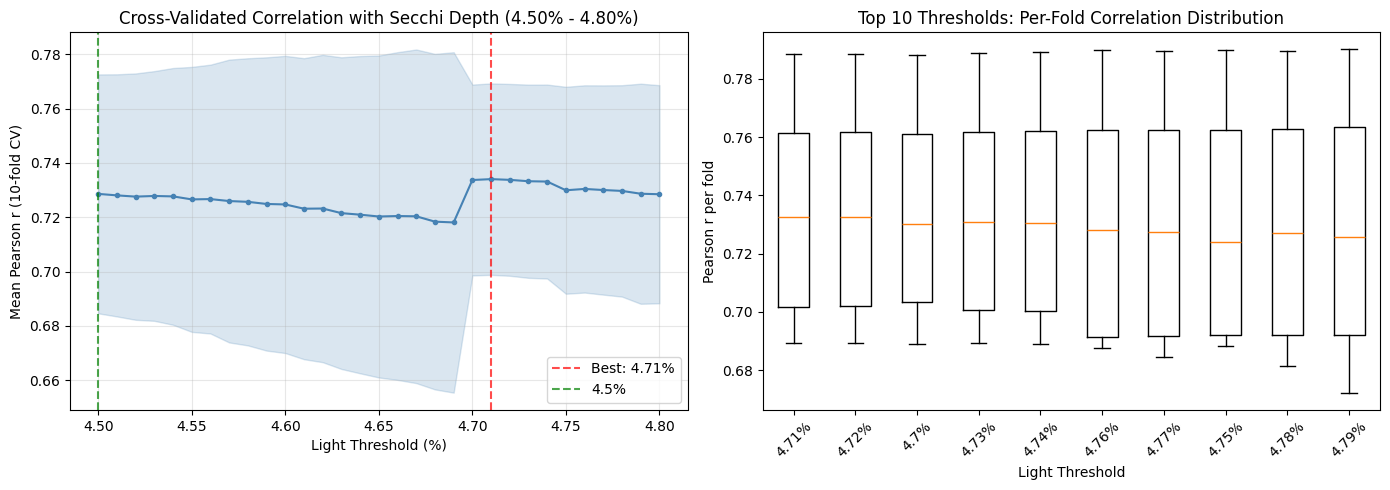

In [6]:
# Cross-validated threshold selection (fine-grained): 4.5% to 4.8% in 0.01% steps
thresholds_cv_fine = [round(x * 0.01, 2) for x in range(450, 481)]

# Pre-compute photic depths for all thresholds and all casts
secchi_per_cast = df3.groupby('CAST_COUNT')['Secchi'].first()

photic_all_fine = {}
for t in thresholds_cv_fine:
    photic_all_fine[t] = df3.groupby('CAST_COUNT').apply(
        lambda g, thresh=t: calculate_photic_depth_at_threshold(g, thresh), include_groups=False
    )

# Build a DataFrame: rows = casts, columns = thresholds + Secchi
cv_df_fine = pd.DataFrame(photic_all_fine)
cv_df_fine['Secchi'] = secchi_per_cast

# Drop casts with no Secchi
cv_df_fine = cv_df_fine.dropna(subset=['Secchi'])

# 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cast_indices = np.arange(len(cv_df_fine))

# Store per-fold correlations for each threshold
fold_correlations_fine = {t: [] for t in thresholds_cv_fine}

for train_idx, test_idx in kf.split(cast_indices):
    test_data = cv_df_fine.iloc[test_idx]
    for t in thresholds_cv_fine:
        valid = test_data[['Secchi', t]].dropna()
        if len(valid) >= 10:
            r = valid['Secchi'].corr(valid[t])
            fold_correlations_fine[t].append(r)
        else:
            fold_correlations_fine[t].append(np.nan)

# Compute mean and std of correlations across folds
mean_corr_fine = {t: np.nanmean(fold_correlations_fine[t]) for t in thresholds_cv_fine}
std_corr_fine = {t: np.nanstd(fold_correlations_fine[t]) for t in thresholds_cv_fine}

# Display results
print("Cross-validated correlation (10-fold) between Secchi and photic depth (4.50% - 4.80%):")
print(f"{'Threshold':>10} {'Mean r':>8} {'Std r':>8}")
print("-" * 28)
for t in thresholds_cv_fine:
    print(f"{t:>9.2f}% {mean_corr_fine[t]:>8.4f} {std_corr_fine[t]:>8.4f}")

best_t_cv_fine = max(mean_corr_fine, key=mean_corr_fine.get)
print(f"\nBest threshold: {best_t_cv_fine}% (mean r = {mean_corr_fine[best_t_cv_fine]:.4f} +/- {std_corr_fine[best_t_cv_fine]:.4f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

means_fine = [mean_corr_fine[t] for t in thresholds_cv_fine]
stds_fine = [std_corr_fine[t] for t in thresholds_cv_fine]

axes[0].plot(thresholds_cv_fine, means_fine, 'o-', color='steelblue', markersize=3)
axes[0].fill_between(thresholds_cv_fine, 
                      [m - s for m, s in zip(means_fine, stds_fine)],
                      [m + s for m, s in zip(means_fine, stds_fine)],
                      alpha=0.2, color='steelblue')
axes[0].axvline(x=best_t_cv_fine, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_t_cv_fine}%')
axes[0].axvline(x=4.5, color='green', linestyle='--', alpha=0.7, label='4.5%')
axes[0].set_xlabel('Light Threshold (%)')
axes[0].set_ylabel('Mean Pearson r (10-fold CV)')
axes[0].set_title('Cross-Validated Correlation with Secchi Depth (4.50% - 4.80%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot of per-fold correlations for top candidates
top_thresholds_fine = sorted(mean_corr_fine, key=mean_corr_fine.get, reverse=True)[:10]
box_data_fine = [fold_correlations_fine[t] for t in top_thresholds_fine]
axes[1].boxplot(box_data_fine, labels=[f'{t}%' for t in top_thresholds_fine])
axes[1].set_xlabel('Light Threshold')
axes[1].set_ylabel('Pearson r per fold')
axes[1].set_title('Top 10 Thresholds: Per-Fold Correlation Distribution')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Choosing the photic depth threshold of 4.7% seems like the most logical option since 4.71% increases R only marginally. 